# Spectral_Analysis — part 3 of 7

This notebook was automatically split from a larger notebook.

Running expert exploratory wavelet bandpower analysis
FAST_OPTION: fast
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Wavelet fs: 250.0 Hz
Frequencies: 1.00 to 100.00 Hz, n=40
Morlet cycles: 6.0, support sigma: 3.5
Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled wavelet segment shape: (26736, 32)
[01/32] Fp1 | alpha=0.043 | gamma=0.545 | alpha burst=0.141 | 0.06s
[02/32] Fpz | alpha=0.047 | gamma=0.523 | alpha burst=0.151 | 0.05s
[03/32] Fp2 | alpha=0.045 | gamma=0.537 | alpha burst=0.149 | 0.05s
[04/32]  F7 | alpha=0.035 | gamma=0.715 | alpha burst=0.155 | 0.04s
[05/32]  F3 | alpha=0.033 | gamma=0.744 | alpha burst=0.161 | 0.04s
[06/32]  Fz | alpha=0.047 | gamma=0.649 | alpha burst=0.156 | 0.04s
[07/32]  F4 | alpha=0.041 | gamma=0.718 | alpha burst=0.154 | 0.04s
[08/32]  F8 | alpha=0.046 | gamma=0.682 | alpha burst=0.167 | 0.04s
[09/32] FC5 | alpha=0.030 

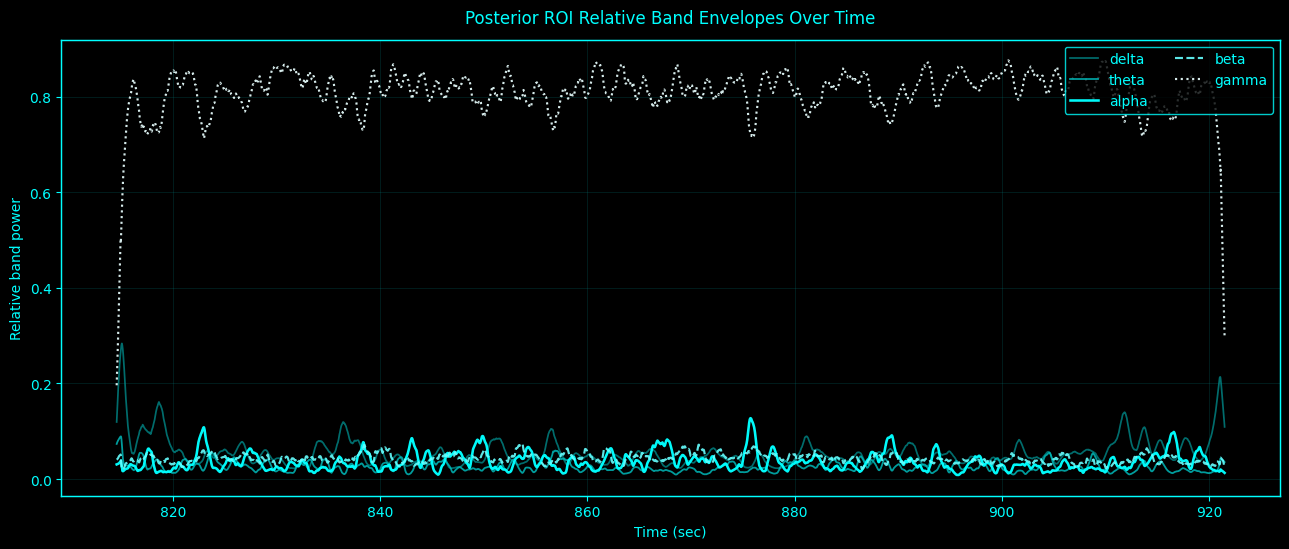

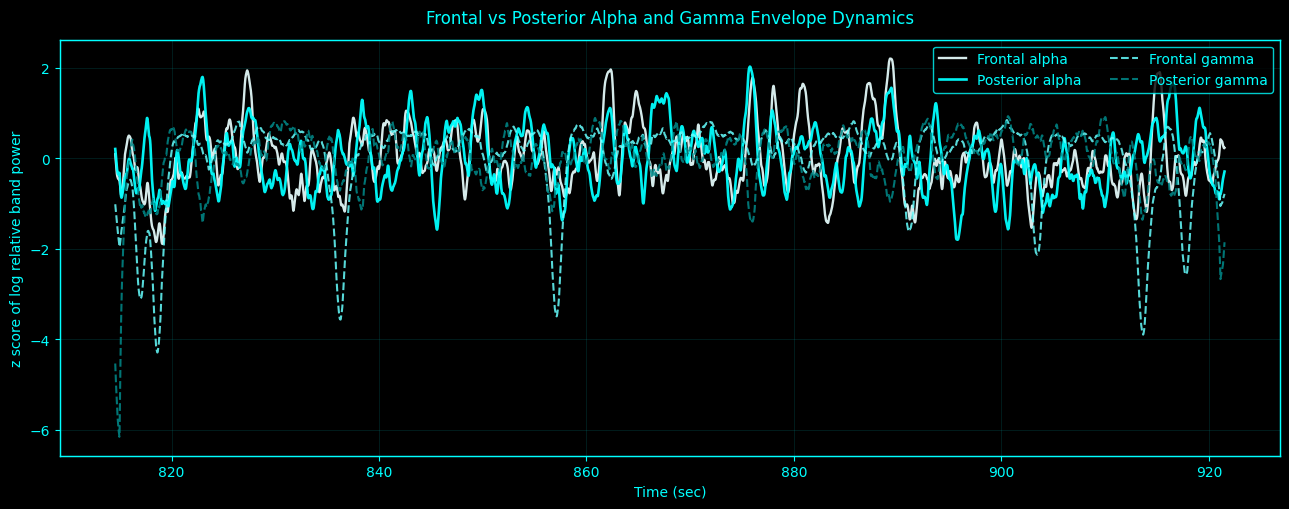

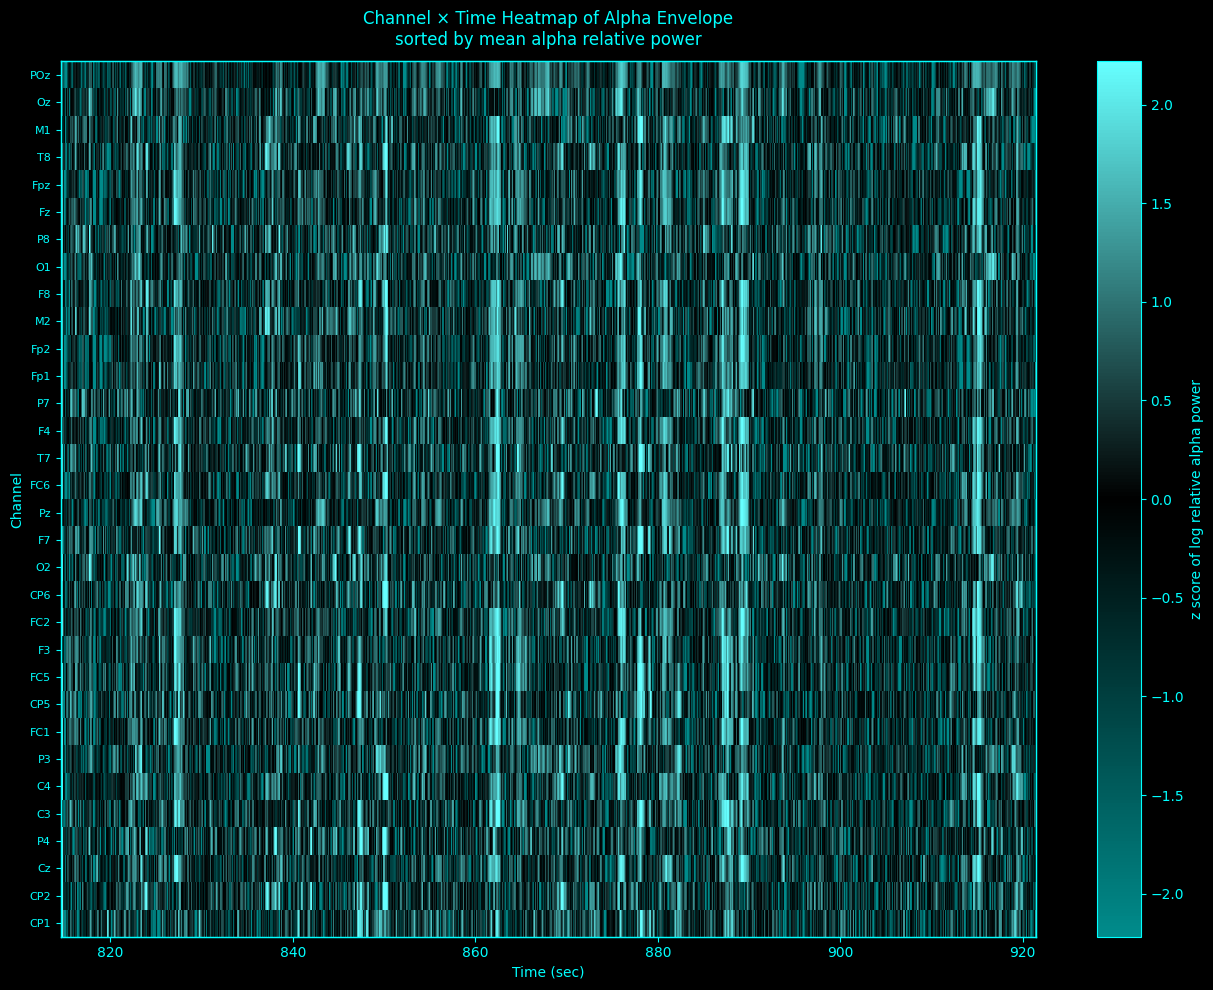

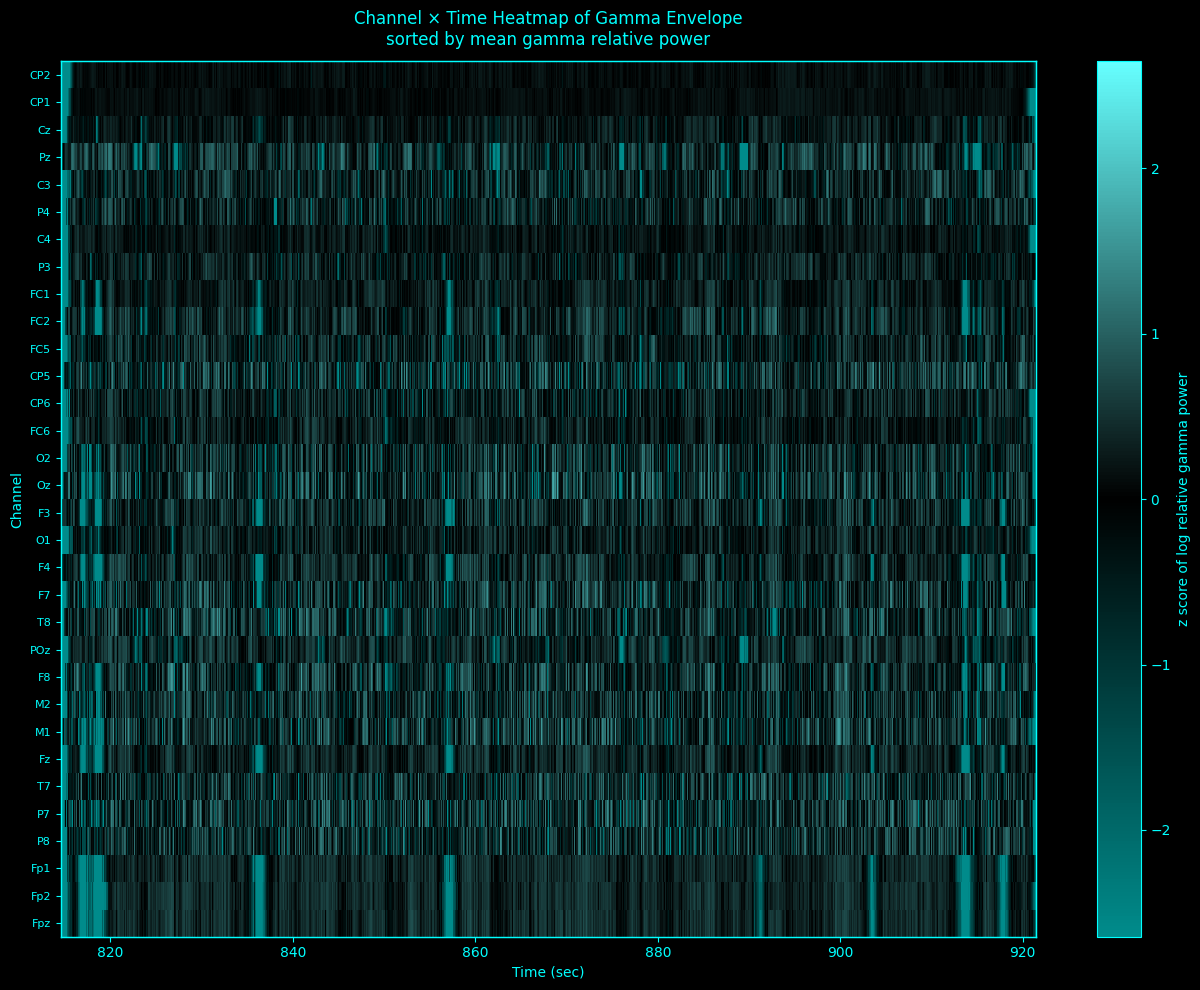

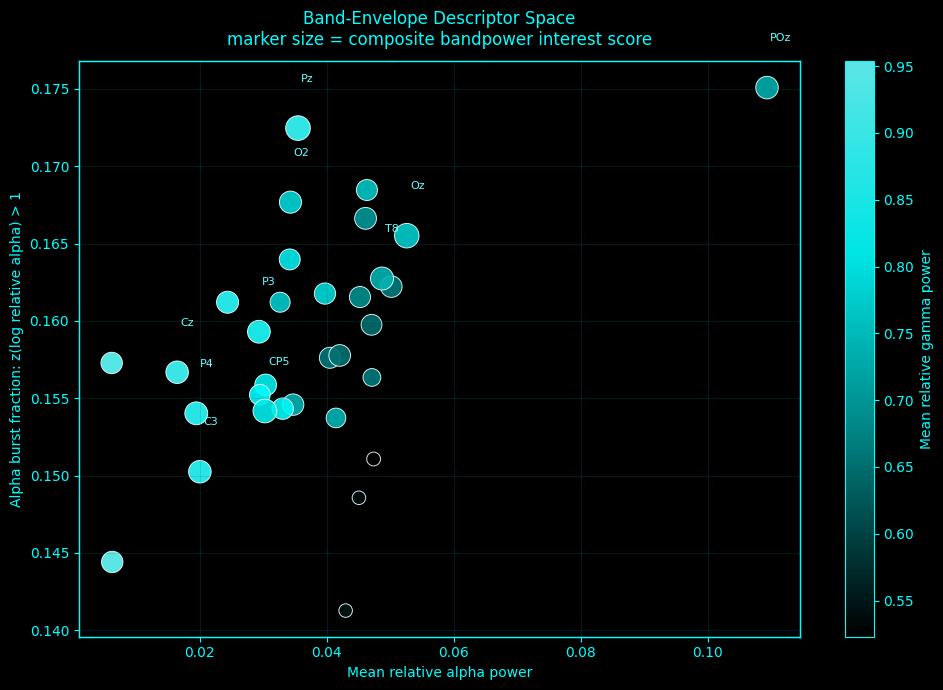

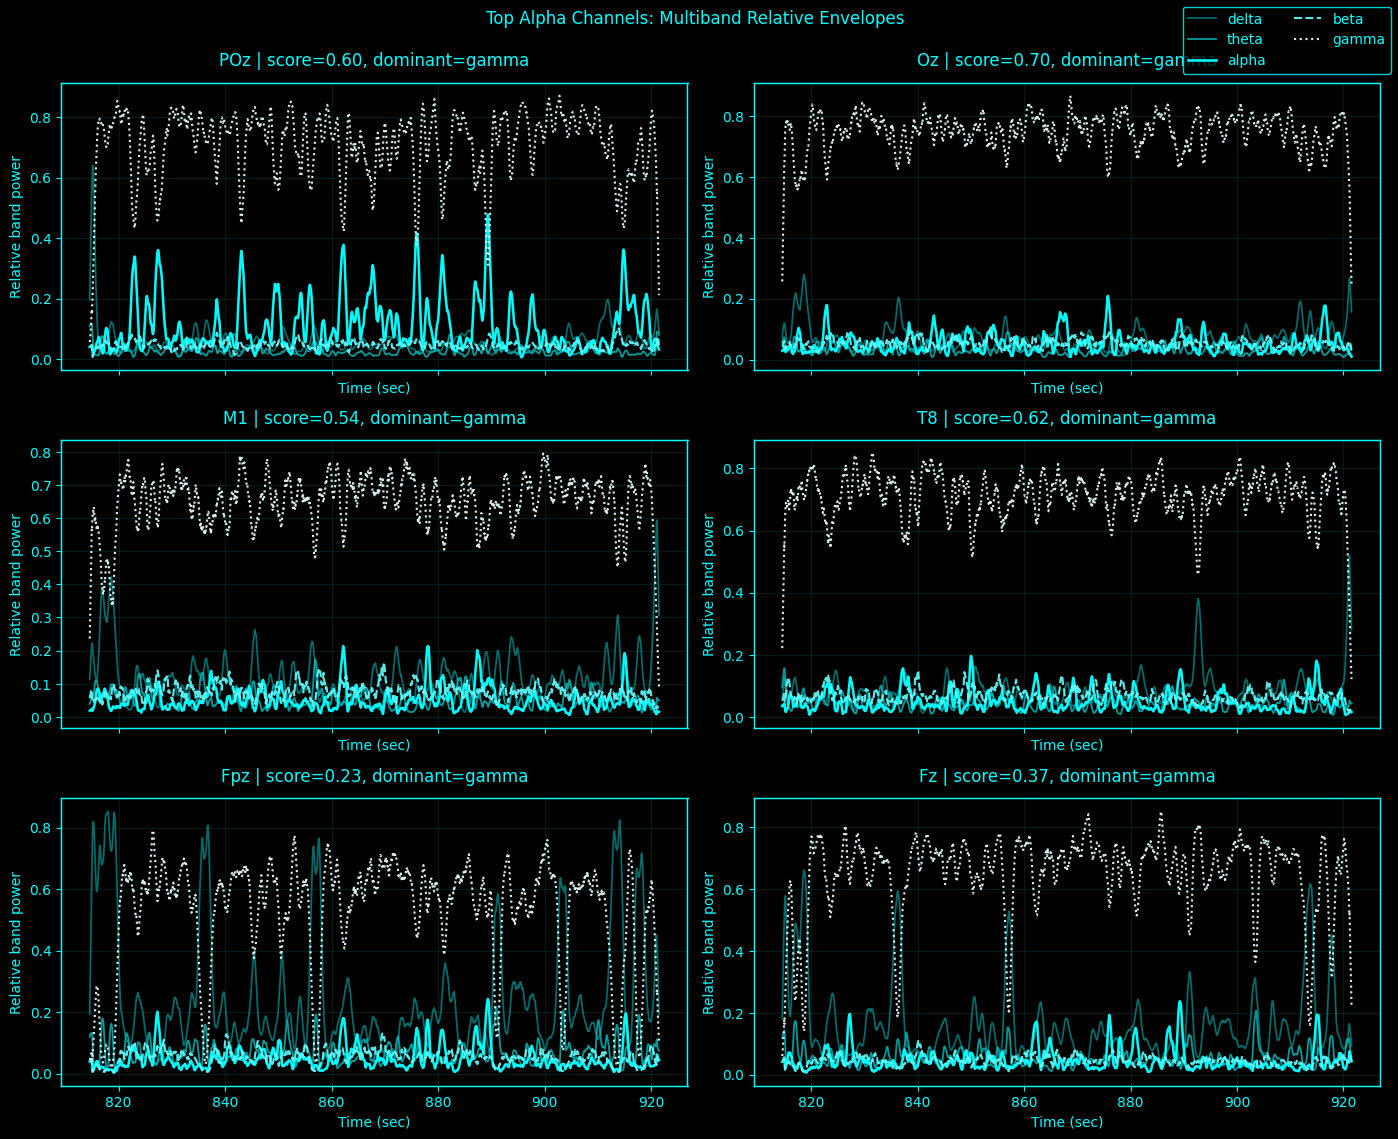

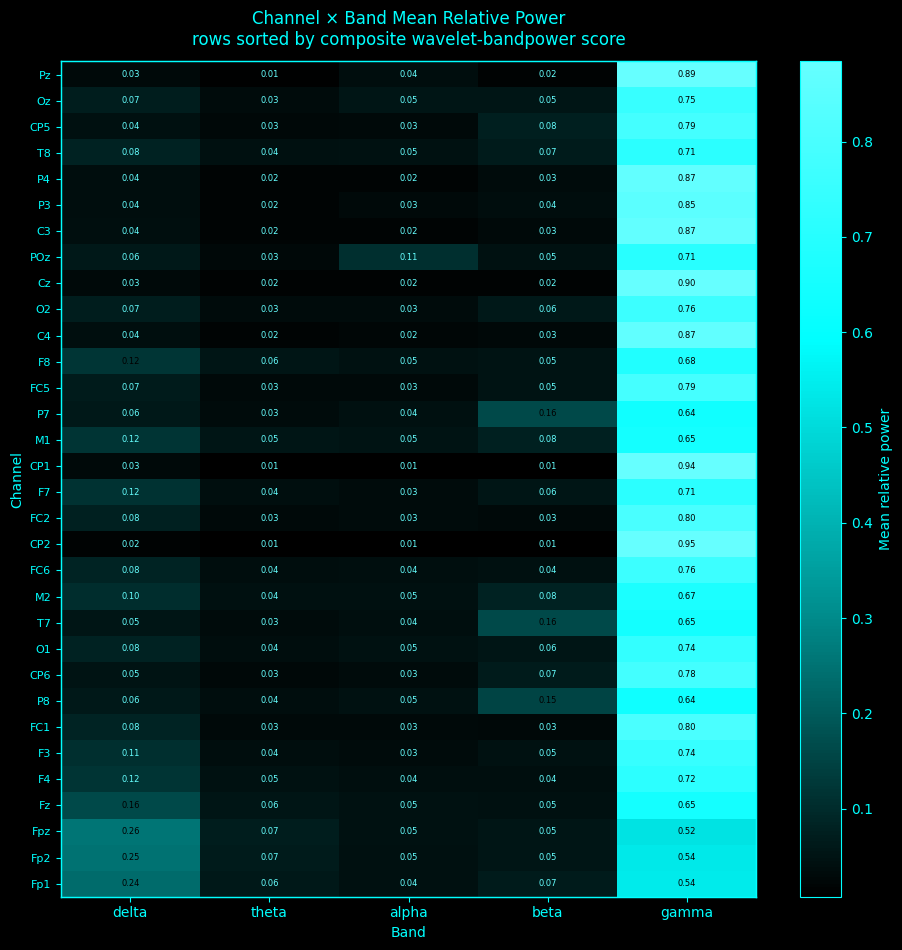

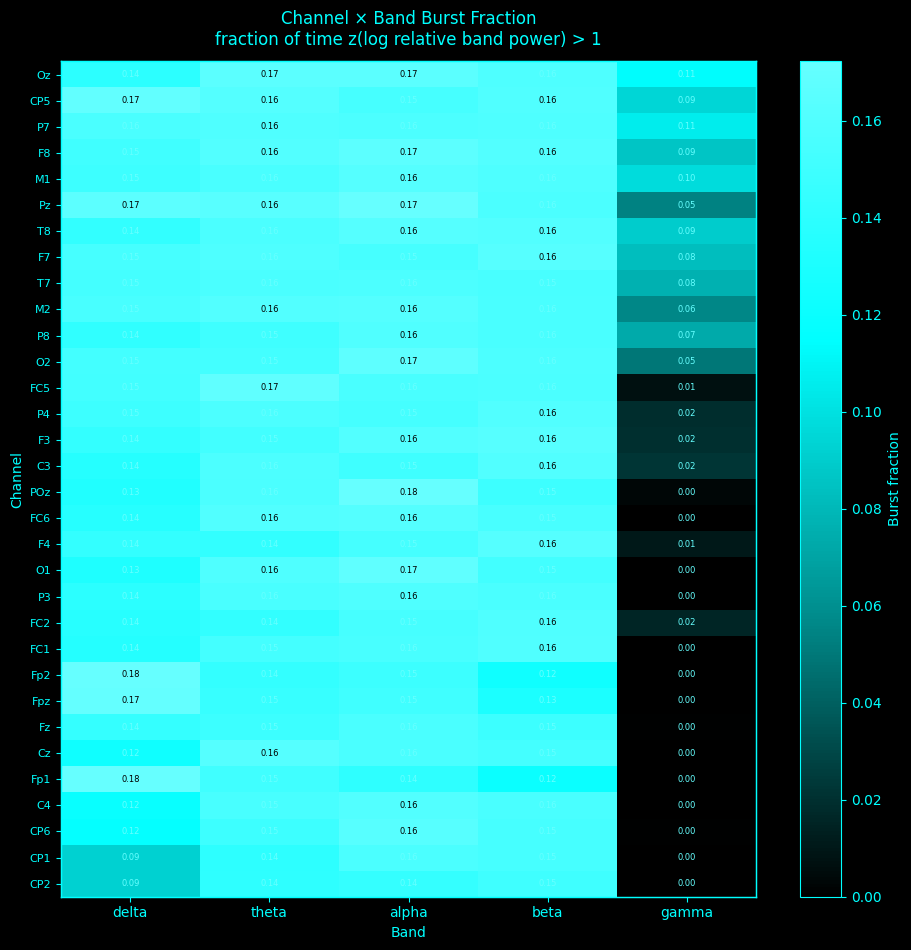

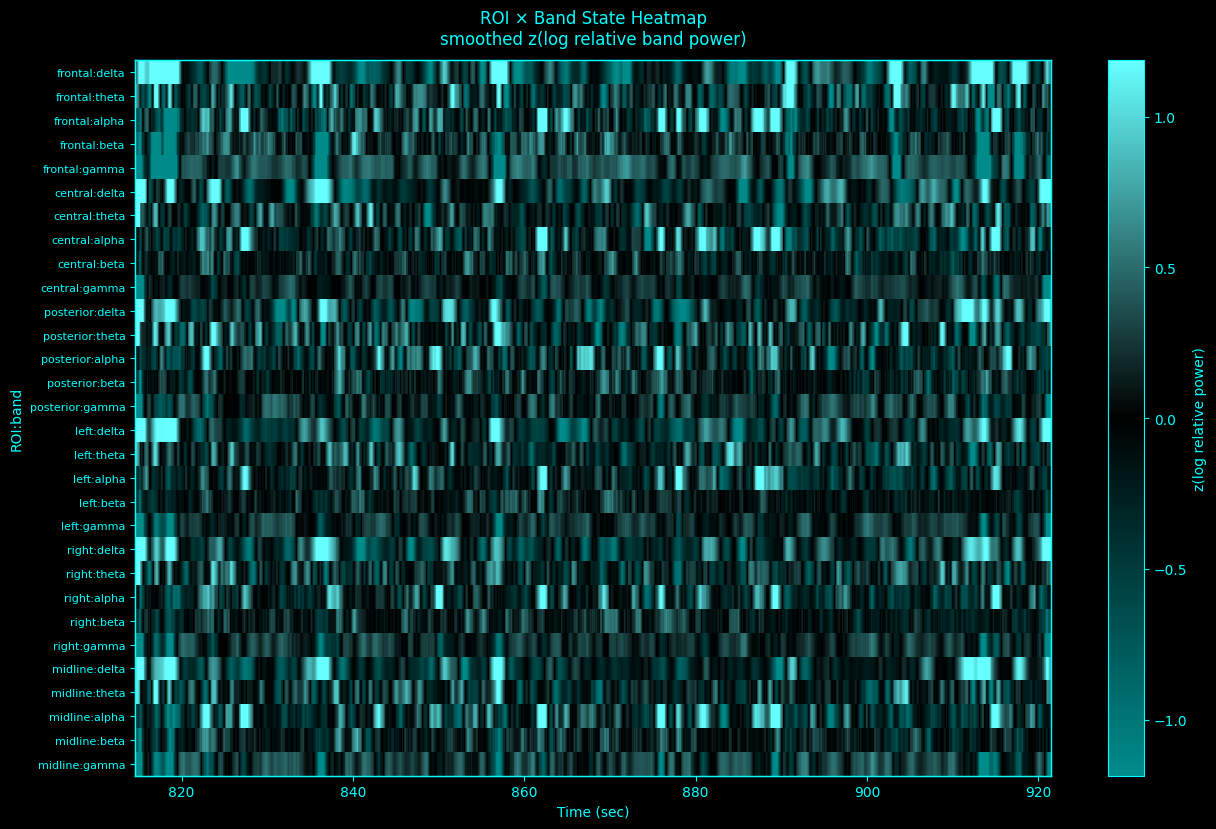

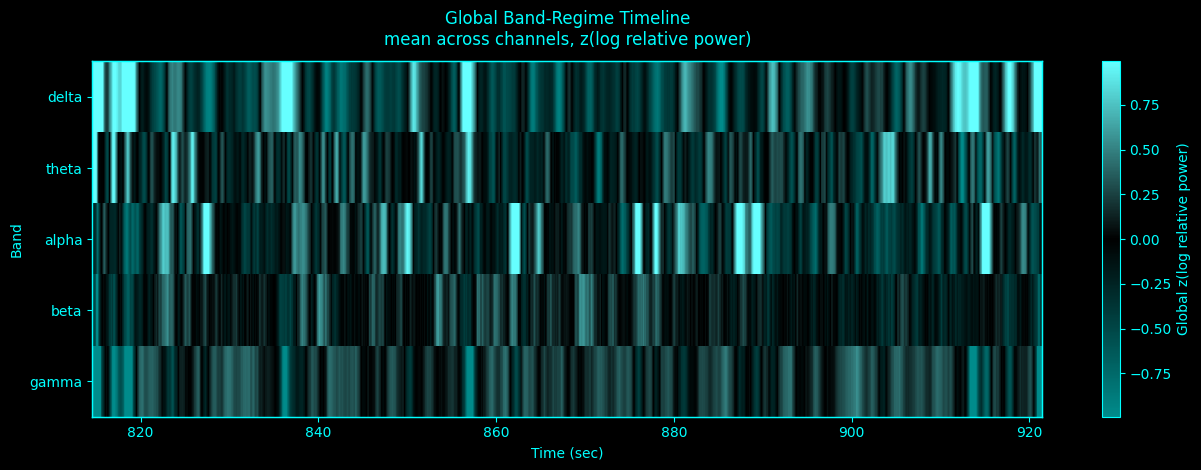

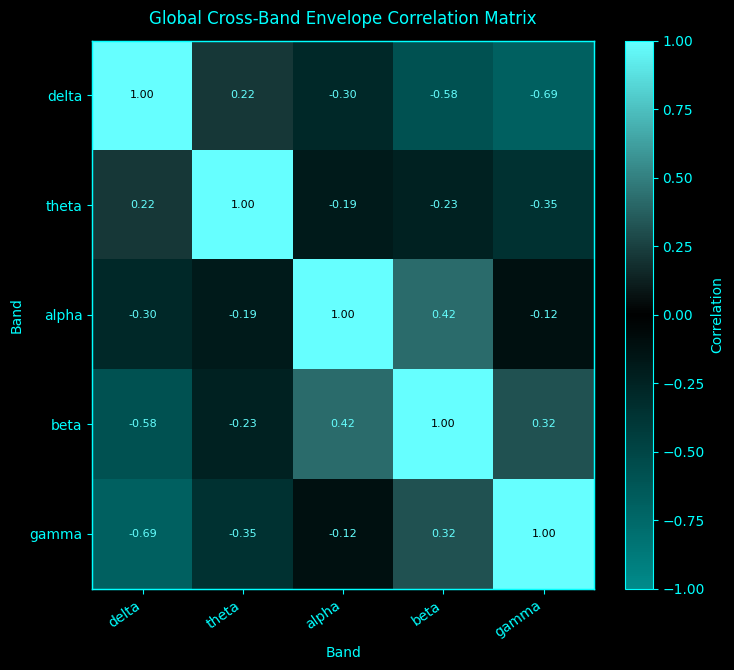

/tmp/ipykernel_752526/2946137389.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


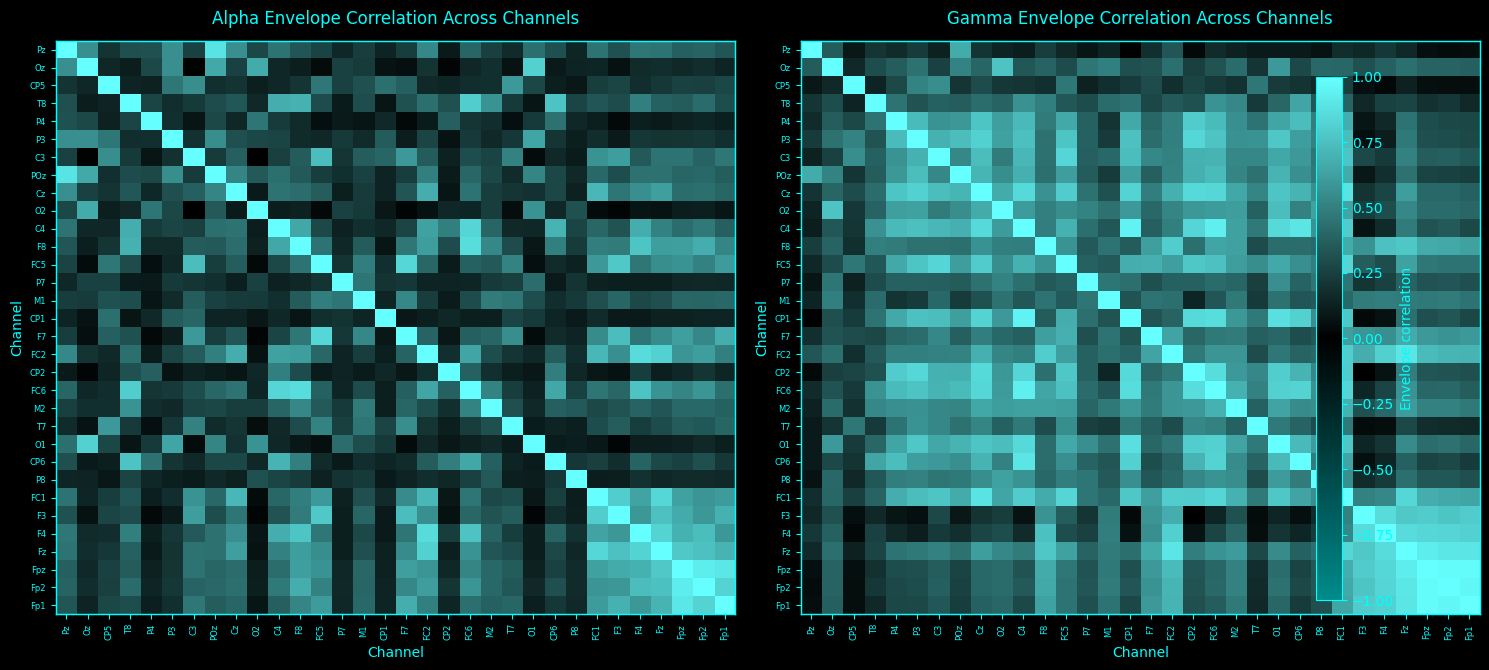

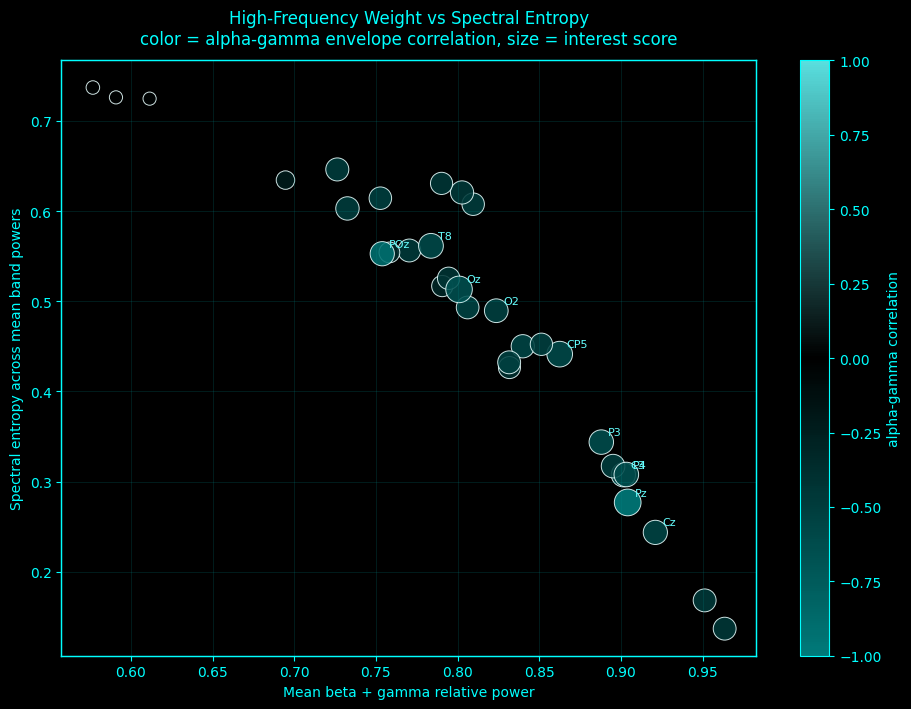

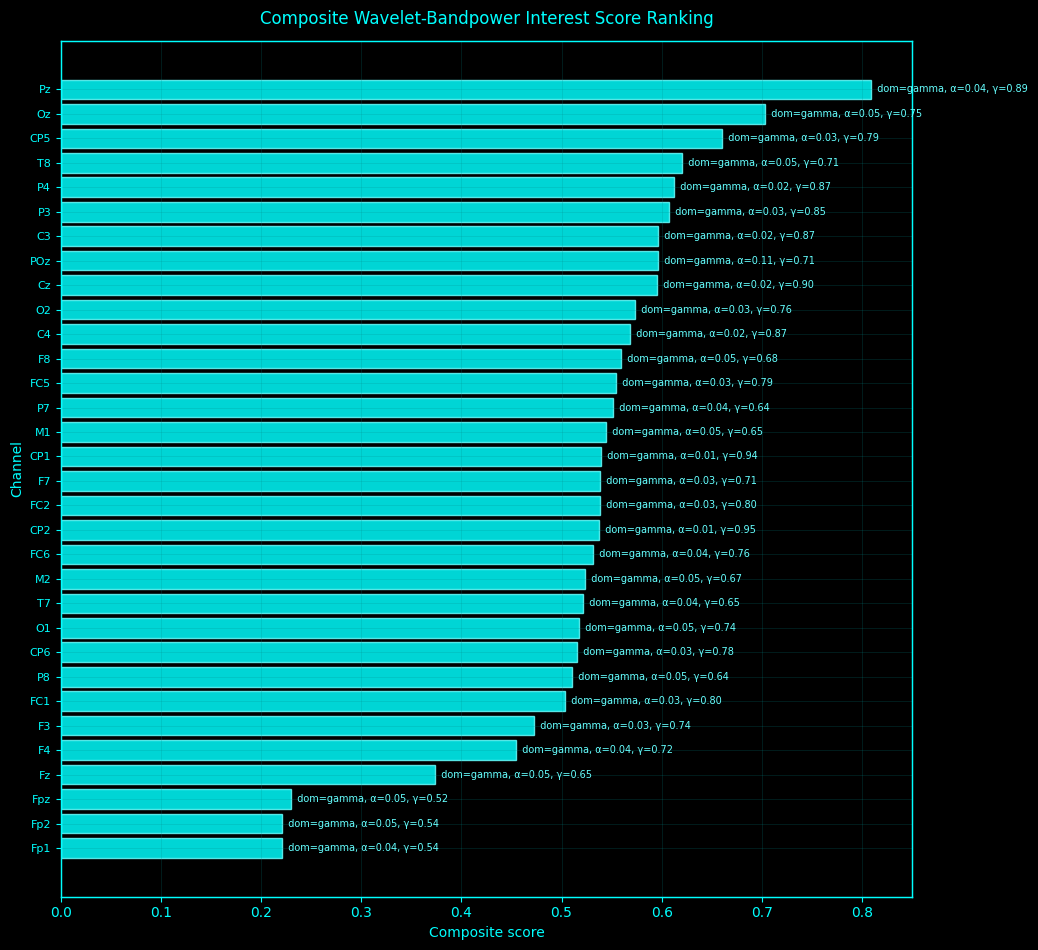

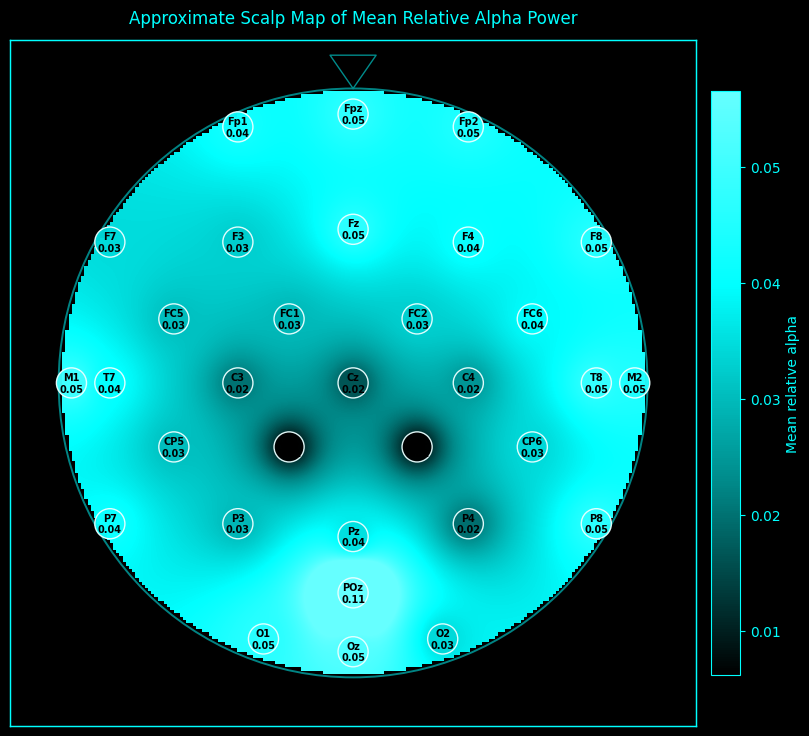

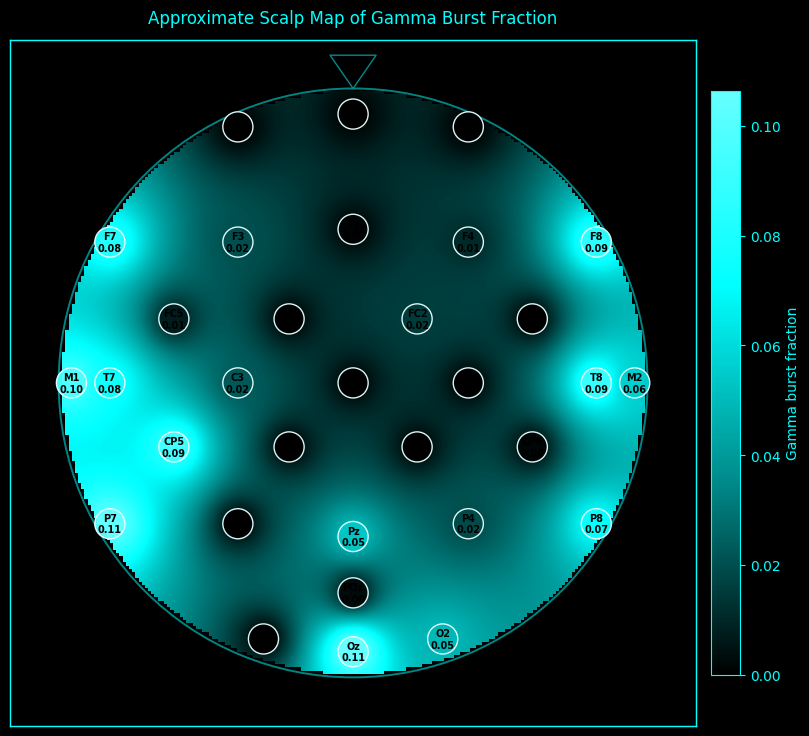

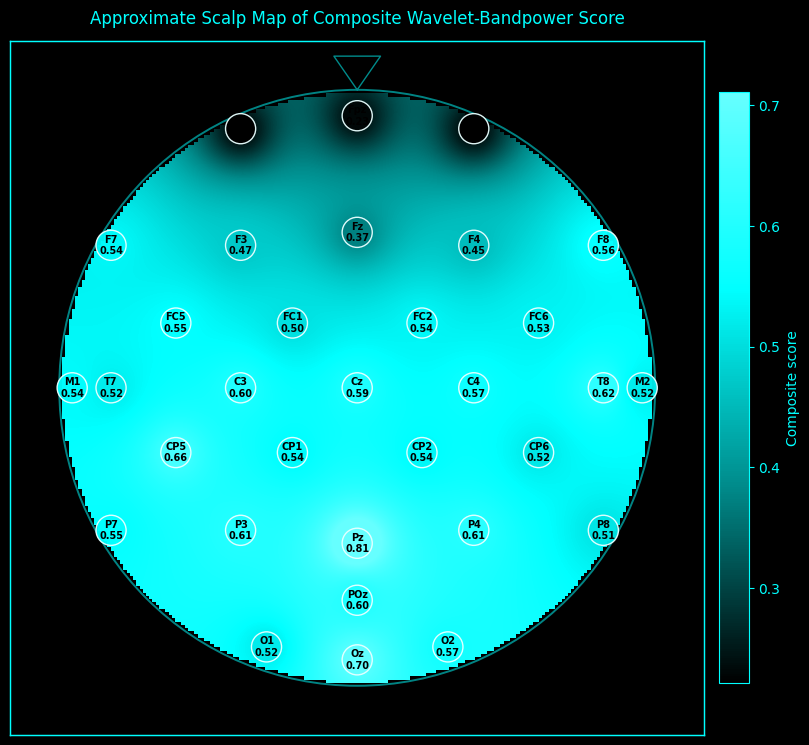

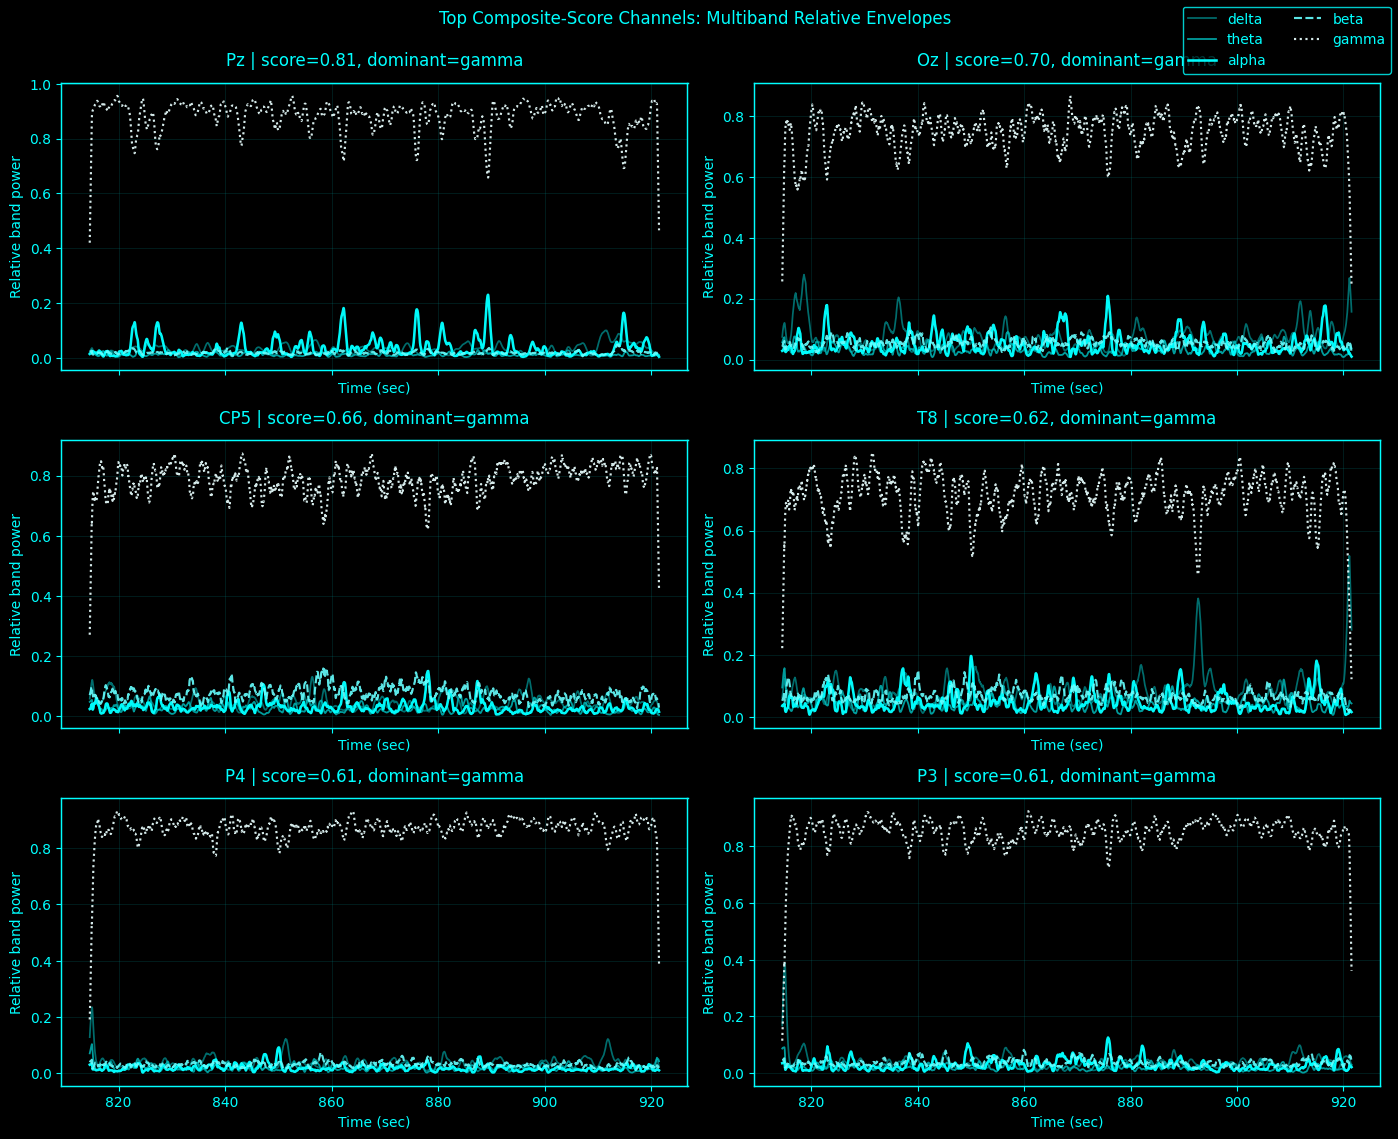


EXPERT WAVELET BANDPOWER SUMMARY
FAST_OPTION: fast
Original segment shape: (106944, 32)
Downsampled wavelet segment shape: (26736, 32)
Wavelet sampling rate: 250.0 Hz
Frequency range: 1.00–100.00 Hz
Wavelet frequencies: 40
Morlet cycles: 6.0
Channels analyzed: 32
Elapsed: 0.31 min

Top 15 channels by composite wavelet-bandpower interest score:
channel  wavelet_bandpower_interest_score dominant_band  alpha_relative_mean  gamma_relative_mean  alpha_burst_fraction_z_gt_1  gamma_burst_fraction_z_gt_1  spectral_entropy_relative_means  alpha_gamma_corr hemisphere           region
     Pz                          0.809538         gamma             0.035463             0.886418                     0.172464                     0.053897                         0.276969         -0.900208    midline         parietal
     Oz                          0.703507         gamma             0.052601             0.747225                     0.165507                     0.113704                         0.5

In [1]:
import os
import time
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

FAST_OPTION = "fast"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    wavelet_downsample_factor = 4
    fmin = 1.0
    fmax = 95.0
    n_wavelet_freqs = 28
    morlet_n_cycles = 5.0
    morlet_support_sigma = 3.2
    display_smoothing_sec = 1.00
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = False
    save_full_band_dict = True
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 170
    top_trace_n = 4
    heatmap_max_time_bins = 1800
    topographic_grid_n = 160
    zip_outputs = False

elif FAST_OPTION == "fast":
    wavelet_downsample_factor = 4
    fmin = 1.0
    fmax = 100.0
    n_wavelet_freqs = 40
    morlet_n_cycles = 6.0
    morlet_support_sigma = 3.5
    display_smoothing_sec = 0.75
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = False
    save_full_band_dict = True
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 190
    top_trace_n = 6
    heatmap_max_time_bins = 2400
    topographic_grid_n = 190
    zip_outputs = True

elif FAST_OPTION == "balanced":
    wavelet_downsample_factor = 4
    fmin = 1.0
    fmax = 100.0
    n_wavelet_freqs = 56
    morlet_n_cycles = 7.0
    morlet_support_sigma = 4.0
    display_smoothing_sec = 0.75
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = False
    save_full_band_dict = True
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 220
    top_trace_n = 8
    heatmap_max_time_bins = 3200
    topographic_grid_n = 220
    zip_outputs = True

elif FAST_OPTION == "full":
    wavelet_downsample_factor = 2
    fmin = 1.0
    fmax = 100.0
    n_wavelet_freqs = 72
    morlet_n_cycles = 7.0
    morlet_support_sigma = 4.0
    display_smoothing_sec = 0.50
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = False
    save_full_band_dict = True
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 240
    top_trace_n = 10
    heatmap_max_time_bins = 5000
    topographic_grid_n = 260
    zip_outputs = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


out_dir = os.path.join(base_dir, "results", "exploratory_wavelet_bandpowers_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
expert_plots_dir = os.path.join(plots_dir, "expert")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(expert_plots_dir, exist_ok=True)


sampling_rate = 1000
start_time = 814.571
end_time = 921.515
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

fs_wavelet = sampling_rate / wavelet_downsample_factor
effective_fmax = min(fmax, 0.45 * fs_wavelet)
target_freqs_hz = np.geomspace(fmin, effective_fmax, n_wavelet_freqs)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

roi_definitions = {
    "frontal": ["Fp1", "Fpz", "Fp2", "F3", "Fz", "F4"],
    "central": ["C3", "Cz", "C4"],
    "posterior": ["P3", "Pz", "P4", "O1", "Oz", "O2"],
    "left": left_channels,
    "right": right_channels,
    "midline": midline_channels,
}

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

band_specs = {
    "delta": [(1.0, 4.0)],
    "theta": [(4.0, 8.0)],
    "alpha": [(8.0, 13.0)],
    "beta": [(13.0, 30.0)],
    "gamma": [(30.0, 58.0), (62.0, 100.0)],
}

total_band_spec = [(1.0, 58.0), (62.0, 100.0)]
band_names = list(band_specs.keys())

eps = 1e-12

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 10,
})

band_styles = {
    "delta": {"color": ACCENT_DIM, "linestyle": "-", "linewidth": 1.25, "alpha": 0.78},
    "theta": {"color": "#00BFBF", "linestyle": "-", "linewidth": 1.30, "alpha": 0.82},
    "alpha": {"color": ACCENT, "linestyle": "-", "linewidth": 1.85, "alpha": 0.98},
    "beta": {"color": ACCENT_SOFT, "linestyle": "--", "linewidth": 1.55, "alpha": 0.90},
    "gamma": {"color": WHITE, "linestyle": ":", "linewidth": 1.55, "alpha": 0.92},
}


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.05)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.65)
    else:
        ax.grid(False)


def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)

    for lab in cbar.ax.get_yticklabels():
        lab.set_color(ACCENT)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if save_plots_to_disk and path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)

    if show_plots_in_notebook and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    elif show_plots_in_notebook and show:
        plt.show()

    plt.close(fig)


def safe_numeric_array(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isfinite(x), x, np.nan)


def robust_minmax(x, lo=3, hi=97):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    a = np.nanpercentile(finite, lo)
    b = np.nanpercentile(finite, hi)

    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
        return np.zeros_like(x, dtype=float)

    return np.clip((x - a) / (b - a + eps), 0, 1)


def robust_z(x):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    med = np.nanmedian(finite)
    q25 = np.nanpercentile(finite, 25)
    q75 = np.nanpercentile(finite, 75)
    iqr = q75 - q25

    if not np.isfinite(iqr) or iqr <= eps:
        return (x - med) / (np.nanstd(finite) + eps)

    return (x - med) / (iqr + eps)


def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    if x.shape[1] > n_channels_expected:
        return x[:, :n_channels_expected]

    if x.shape[0] > n_channels_expected:
        return x.T[:, :n_channels_expected]

    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")


def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x

    return x - np.mean(x, axis=1, keepdims=True)


def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    y = np.where(np.isfinite(y), y, np.nan)

    if np.any(~np.isfinite(y)):
        med = np.nanmedian(y)
        if not np.isfinite(med):
            med = 0.0
        y = np.nan_to_num(y, nan=med, posinf=med, neginf=med)

    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)

    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)

    return y


def smooth_1d(x, win):
    x = np.asarray(x, dtype=float)

    if win <= 1 or len(x) < win:
        return x

    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")


def smooth_time_series(x, fs, smoothing_sec=0.75):
    win = max(int(round(fs * smoothing_sec)), 1)

    if win % 2 == 0:
        win += 1

    return smooth_1d(x, win=win)


def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)


def percentile_limits(x, lo=2, hi=98, symmetric=False):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return None, None

    lo_v = float(np.percentile(x, lo))
    hi_v = float(np.percentile(x, hi))

    if symmetric:
        m = max(abs(lo_v), abs(hi_v), eps)
        return -m, m

    if hi_v <= lo_v:
        lo_v = float(np.min(x))
        hi_v = float(np.max(x))

        if hi_v <= lo_v:
            hi_v = lo_v + 1e-6

    return lo_v, hi_v


def band_mask(freqs_hz, lo, hi):
    return (freqs_hz >= lo) & (freqs_hz <= hi)


def integrate_composite_band(freqs_hz, values, band_list, axis=0):
    total = None

    for lo, hi in band_list:
        mask = band_mask(freqs_hz, lo, hi)

        if np.sum(mask) < 2:
            continue

        piece = integrate_trapezoid(values[mask], freqs_hz[mask], axis=axis)

        if total is None:
            total = np.asarray(piece, dtype=float)
        else:
            total = total + np.asarray(piece, dtype=float)

    if total is None:
        if values.ndim == 1:
            return np.nan
        return np.full(values.shape[1], np.nan, dtype=float)

    return total


def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]

    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan, dtype=float)

    return np.nanmean(matrix[:, idx], axis=1)


def morlet_wavelet(f_hz, fs, n_cycles=7.0, support_sigma=4.0):
    sigma_t = n_cycles / (2.0 * np.pi * f_hz)
    half_width_sec = support_sigma * sigma_t
    t = np.arange(-half_width_sec, half_width_sec + 1.0 / fs, 1.0 / fs)

    wavelet = np.exp(2j * np.pi * f_hz * t) * np.exp(-(t ** 2) / (2.0 * sigma_t ** 2))
    wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2) + eps)

    return wavelet


def compute_morlet_cwt_power(y, fs, target_freqs_hz, n_cycles=7.0, support_sigma=4.0):
    y = np.asarray(y, dtype=float)
    power_rows = []

    for f_hz in target_freqs_hz:
        w = morlet_wavelet(f_hz, fs, n_cycles=n_cycles, support_sigma=support_sigma)
        coeff = signal.fftconvolve(y, np.conjugate(w[::-1]), mode="same")
        power_rows.append(np.abs(coeff) ** 2)

    power_matrix = np.vstack(power_rows)

    return np.asarray(target_freqs_hz, dtype=float), power_matrix


def downsample_for_heatmap(M, time_values, max_bins):
    M = np.asarray(M, dtype=float)

    if max_bins is None or M.shape[-1] <= max_bins:
        return M, time_values

    step = int(np.ceil(M.shape[-1] / max_bins))
    slicer = [slice(None)] * M.ndim
    slicer[-1] = slice(0, M.shape[-1], step)

    return M[tuple(slicer)], time_values[::step]


def add_channel_metadata(df):
    df = df.copy()
    hemispheres = []
    regions = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemispheres.append("left")
        elif ch in right_channels:
            hemispheres.append("right")
        elif ch in midline_channels:
            hemispheres.append("midline")
        else:
            hemispheres.append("unknown")

        if ch.startswith("Fp"):
            regions.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            regions.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            regions.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            regions.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            regions.append("occipital")
        else:
            regions.append("unknown")

    df["hemisphere"] = hemispheres
    df["region"] = regions

    return df


def add_expert_band_metrics(summary_df):
    df = summary_df.copy()

    mean_cols = [f"{b}_relative_mean" for b in band_names]
    std_cols = [f"{b}_relative_std" for b in band_names]
    burst_cols = [f"{b}_burst_fraction_z_gt_1" for b in band_names]

    mean_matrix = df[mean_cols].to_numpy(dtype=float)
    mean_matrix = np.where(np.isfinite(mean_matrix), mean_matrix, 0.0)
    mean_sum = np.sum(mean_matrix, axis=1, keepdims=True) + eps
    p = mean_matrix / mean_sum

    entropy = -np.sum(p * np.log(p + eps), axis=1) / np.log(len(band_names))
    dominant_idx = np.nanargmax(mean_matrix, axis=1)
    dominant_band = [band_names[i] for i in dominant_idx]

    df["spectral_entropy_relative_means"] = entropy
    df["spectral_concentration"] = 1.0 - entropy
    df["dominant_band"] = dominant_band

    df["low_freq_relative_mean"] = df["delta_relative_mean"] + df["theta_relative_mean"]
    df["mid_freq_relative_mean"] = df["alpha_relative_mean"] + df["beta_relative_mean"]
    df["high_freq_relative_mean"] = df["beta_relative_mean"] + df["gamma_relative_mean"]

    df["alpha_theta_ratio_mean"] = df["alpha_relative_mean"] / (df["theta_relative_mean"] + eps)
    df["beta_gamma_ratio_mean"] = df["beta_relative_mean"] / (df["gamma_relative_mean"] + eps)
    df["gamma_alpha_balance"] = df["gamma_relative_mean"] - df["alpha_relative_mean"]

    burst_matrix = df[burst_cols].to_numpy(dtype=float)
    df["mean_band_burst_fraction_z_gt_1"] = np.nanmean(burst_matrix, axis=1)
    df["max_band_burst_fraction_z_gt_1"] = np.nanmax(burst_matrix, axis=1)

    std_matrix = df[std_cols].to_numpy(dtype=float)
    df["mean_band_variability"] = np.nanmean(std_matrix, axis=1)

    df["wavelet_bandpower_interest_score"] = (
        0.22 * robust_minmax(df["alpha_relative_mean"].to_numpy(dtype=float))
        + 0.18 * robust_minmax(df["gamma_relative_mean"].to_numpy(dtype=float))
        + 0.18 * robust_minmax(df["mean_band_burst_fraction_z_gt_1"].to_numpy(dtype=float))
        + 0.16 * robust_minmax(df["spectral_concentration"].to_numpy(dtype=float))
        + 0.14 * robust_minmax(df["high_freq_relative_mean"].to_numpy(dtype=float))
        + 0.12 * robust_minmax(np.abs(df["alpha_gamma_corr"].to_numpy(dtype=float)))
    )

    return df


def plot_posterior_roi_relative_band_envelopes(band_rel_matrix, path):
    posterior_band_rel = np.full((n_times, n_bands), np.nan, dtype=float)

    for b_i in range(n_bands):
        posterior_band_rel[:, b_i] = roi_average_matrix(
            band_rel_matrix[:, :, b_i],
            eeg_channel_names,
            roi_definitions["posterior"],
        )

    fig, ax = plt.subplots(figsize=(13, 5.6), facecolor=BLACK)

    for b_i, band_name in enumerate(band_names):
        y = smooth_time_series(posterior_band_rel[:, b_i], fs_wavelet, smoothing_sec=display_smoothing_sec)
        style = band_styles[band_name]
        ax.plot(time_ds_abs, y, label=band_name, **style)

    style_ax(
        ax,
        title="Posterior ROI Relative Band Envelopes Over Time",
        xlabel="Time (sec)",
        ylabel="Relative band power",
    )

    leg = ax.legend(loc="upper right", ncol=2, frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_frontal_vs_posterior_alpha_gamma(path):
    frontal_alpha = roi_average_matrix(band_rel_matrix[:, :, alpha_idx], eeg_channel_names, roi_definitions["frontal"])
    posterior_alpha = roi_average_matrix(band_rel_matrix[:, :, alpha_idx], eeg_channel_names, roi_definitions["posterior"])
    frontal_gamma = roi_average_matrix(band_rel_matrix[:, :, gamma_idx], eeg_channel_names, roi_definitions["frontal"])
    posterior_gamma = roi_average_matrix(band_rel_matrix[:, :, gamma_idx], eeg_channel_names, roi_definitions["posterior"])

    fig, ax = plt.subplots(figsize=(13, 5.2), facecolor=BLACK)

    ax.plot(
        time_ds_abs,
        smooth_time_series(zscore_1d(np.log10(frontal_alpha + eps)), fs_wavelet, display_smoothing_sec),
        color=WHITE,
        linewidth=1.7,
        alpha=0.92,
        label="Frontal alpha",
    )

    ax.plot(
        time_ds_abs,
        smooth_time_series(zscore_1d(np.log10(posterior_alpha + eps)), fs_wavelet, display_smoothing_sec),
        color=ACCENT,
        linewidth=1.9,
        alpha=0.95,
        label="Posterior alpha",
    )

    ax.plot(
        time_ds_abs,
        smooth_time_series(zscore_1d(np.log10(frontal_gamma + eps)), fs_wavelet, display_smoothing_sec),
        color=ACCENT_SOFT,
        linewidth=1.5,
        alpha=0.85,
        linestyle="--",
        label="Frontal gamma",
    )

    ax.plot(
        time_ds_abs,
        smooth_time_series(zscore_1d(np.log10(posterior_gamma + eps)), fs_wavelet, display_smoothing_sec),
        color=ACCENT_DIM,
        linewidth=1.5,
        alpha=0.85,
        linestyle="--",
        label="Posterior gamma",
    )

    style_ax(
        ax,
        title="Frontal vs Posterior Alpha and Gamma Envelope Dynamics",
        xlabel="Time (sec)",
        ylabel="z score of log relative band power",
    )

    leg = ax.legend(loc="upper right", ncol=2, frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_band_time_heatmap(heat, sorted_channels, title, cbar_label, path, cmap=CYAN_DIVERGING_CMAP):
    heat_ds, time_ds_plot = downsample_for_heatmap(heat, time_ds_abs, heatmap_max_time_bins)
    vmin, vmax = percentile_limits(heat_ds, lo=2, hi=98, symmetric=True)

    fig, ax = plt.subplots(figsize=(13, 10), facecolor=BLACK)

    im = ax.imshow(
        heat_ds,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=[time_ds_plot[0], time_ds_plot[-1], len(sorted_channels), 0],
    )

    ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
    ax.set_yticklabels(sorted_channels, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title=title,
        xlabel="Time (sec)",
        ylabel="Channel",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, cbar_label)

    save_fig(fig, path)

    return path


def plot_bandpower_descriptor_space(summary_df, path):
    fig, ax = plt.subplots(figsize=(10, 7), facecolor=BLACK)

    scatter = ax.scatter(
        summary_df["alpha_relative_mean"].to_numpy(dtype=float),
        summary_df["alpha_burst_fraction_z_gt_1"].to_numpy(dtype=float),
        c=summary_df["gamma_relative_mean"].to_numpy(dtype=float),
        s=95 + 220 * robust_minmax(summary_df["wavelet_bandpower_interest_score"].to_numpy(dtype=float)),
        alpha=0.90,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=0.7,
    )

    annotate_df = summary_df.sort_values("wavelet_bandpower_interest_score", ascending=False).head(10)

    for _, row in annotate_df.iterrows():
        ax.text(
            row["alpha_relative_mean"] + 0.0005,
            row["alpha_burst_fraction_z_gt_1"] + 0.003,
            row["channel"],
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Band-Envelope Descriptor Space\nmarker size = composite bandpower interest score",
        xlabel="Mean relative alpha power",
        ylabel="Alpha burst fraction: z(log relative alpha) > 1",
    )

    cbar = plt.colorbar(scatter, ax=ax)
    style_cbar(cbar, "Mean relative gamma power")

    save_fig(fig, path)

    return path


def plot_top_channels_multiband_traces(summary_df, rank_col, title, filename):
    top_channels = list(summary_df.sort_values(rank_col, ascending=False).head(top_trace_n)["channel"].values)

    if len(top_channels) == 0:
        return None

    n = len(top_channels)
    ncols = 2
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows), facecolor=BLACK, sharex=True, squeeze=False)
    axes = axes.ravel()

    for ax in axes:
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, ch_name in zip(axes, top_channels):
        ax.axis("on")
        ch_idx = eeg_channel_names.index(ch_name)

        for band_name in band_names:
            b_i = band_names.index(band_name)
            y = smooth_time_series(band_rel_matrix[:, ch_idx, b_i], fs_wavelet, display_smoothing_sec)
            style = band_styles[band_name]
            ax.plot(time_ds_abs, y, label=band_name, **style)

        row = summary_df[summary_df["channel"] == ch_name].iloc[0]

        style_ax(
            ax,
            title=f"{ch_name} | score={row['wavelet_bandpower_interest_score']:.2f}, dominant={row['dominant_band']}",
            xlabel="Time (sec)",
            ylabel="Relative band power",
        )

    handles, labels = axes[0].get_legend_handles_labels()
    leg = fig.legend(handles, labels, loc="upper right", ncol=2, frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    fig.suptitle(title, color=ACCENT, y=0.995)

    path = os.path.join(plots_dir, filename)
    save_fig(fig, path)

    return path


def plot_channel_band_mean_heatmap(summary_df, path):
    metric_cols = [f"{b}_relative_mean" for b in band_names]
    df = summary_df.sort_values("wavelet_bandpower_interest_score", ascending=False).copy()
    M = df[metric_cols].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(9.5, max(7, 0.30 * len(df))), facecolor=BLACK)

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=np.nanpercentile(M, 2),
        vmax=np.nanpercentile(M, 98),
    )

    ax.set_xticks(np.arange(len(band_names)))
    ax.set_xticklabels(band_names, color=ACCENT)

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if np.isfinite(M[i, j]):
                ax.text(
                    j,
                    i,
                    f"{M[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=BLACK if M[i, j] > np.nanpercentile(M, 75) else ACCENT_SOFT,
                )

    style_ax(
        ax,
        title="Channel × Band Mean Relative Power\nrows sorted by composite wavelet-bandpower score",
        xlabel="Band",
        ylabel="Channel",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Mean relative power")

    save_fig(fig, path)

    return path


def plot_channel_band_burst_heatmap(summary_df, path):
    metric_cols = [f"{b}_burst_fraction_z_gt_1" for b in band_names]
    df = summary_df.sort_values("mean_band_burst_fraction_z_gt_1", ascending=False).copy()
    M = df[metric_cols].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(9.5, max(7, 0.30 * len(df))), facecolor=BLACK)

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=np.nanpercentile(M, 98),
    )

    ax.set_xticks(np.arange(len(band_names)))
    ax.set_xticklabels(band_names, color=ACCENT)

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if np.isfinite(M[i, j]):
                ax.text(
                    j,
                    i,
                    f"{M[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=BLACK if M[i, j] > np.nanpercentile(M, 75) else ACCENT_SOFT,
                )

    style_ax(
        ax,
        title="Channel × Band Burst Fraction\nfraction of time z(log relative band power) > 1",
        xlabel="Band",
        ylabel="Channel",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Burst fraction")

    save_fig(fig, path)

    return path


def plot_roi_band_state_heatmap(path):
    rows = []
    labels = []

    for roi_name, roi_channels in roi_definitions.items():
        for b_i, band_name in enumerate(band_names):
            trace = roi_average_matrix(
                band_rel_z_matrix[:, :, b_i],
                eeg_channel_names,
                roi_channels,
            )
            rows.append(smooth_time_series(trace, fs_wavelet, display_smoothing_sec))
            labels.append(f"{roi_name}:{band_name}")

    M = np.vstack(rows)
    M_ds, time_ds_plot = downsample_for_heatmap(M, time_ds_abs, heatmap_max_time_bins)
    vmin, vmax = percentile_limits(M_ds, lo=2, hi=98, symmetric=True)

    fig, ax = plt.subplots(figsize=(13, max(7, 0.28 * len(labels))), facecolor=BLACK)

    im = ax.imshow(
        M_ds,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[time_ds_plot[0], time_ds_plot[-1], len(labels), 0],
    )

    ax.set_yticks(np.arange(len(labels)) + 0.5)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="ROI × Band State Heatmap\nsmoothed z(log relative band power)",
        xlabel="Time (sec)",
        ylabel="ROI:band",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "z(log relative power)")

    save_fig(fig, path)

    return path


def plot_global_band_regime_heatmap(path):
    global_rows = []

    for b_i, band_name in enumerate(band_names):
        trace = np.nanmean(band_rel_z_matrix[:, :, b_i], axis=1)
        global_rows.append(smooth_time_series(trace, fs_wavelet, display_smoothing_sec))

    M = np.vstack(global_rows)
    M_ds, time_ds_plot = downsample_for_heatmap(M, time_ds_abs, heatmap_max_time_bins)
    vmin, vmax = percentile_limits(M_ds, lo=2, hi=98, symmetric=True)

    fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BLACK)

    im = ax.imshow(
        M_ds,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[time_ds_plot[0], time_ds_plot[-1], len(band_names), 0],
    )

    ax.set_yticks(np.arange(len(band_names)) + 0.5)
    ax.set_yticklabels(band_names, color=ACCENT)

    style_ax(
        ax,
        title="Global Band-Regime Timeline\nmean across channels, z(log relative power)",
        xlabel="Time (sec)",
        ylabel="Band",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Global z(log relative power)")

    save_fig(fig, path)

    return path


def plot_band_correlation_matrix(path):
    global_rows = []

    for b_i, band_name in enumerate(band_names):
        trace = np.nanmean(band_rel_z_matrix[:, :, b_i], axis=1)
        global_rows.append(smooth_time_series(trace, fs_wavelet, display_smoothing_sec))

    M = np.vstack(global_rows)
    C = np.corrcoef(M)

    fig, ax = plt.subplots(figsize=(7.5, 6.8), facecolor=BLACK)

    im = ax.imshow(
        C,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(band_names)))
    ax.set_xticklabels(band_names, rotation=35, ha="right", color=ACCENT)

    ax.set_yticks(np.arange(len(band_names)))
    ax.set_yticklabels(band_names, color=ACCENT)

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            ax.text(
                j,
                i,
                f"{C[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=BLACK if abs(C[i, j]) > 0.7 else ACCENT_SOFT,
            )

    style_ax(
        ax,
        title="Global Cross-Band Envelope Correlation Matrix",
        xlabel="Band",
        ylabel="Band",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Correlation")

    save_fig(fig, path)

    return path


def plot_channel_envelope_correlation_gallery(path):
    alpha_corr = np.corrcoef(band_rel_z_matrix[:, :, alpha_idx].T)
    gamma_corr = np.corrcoef(band_rel_z_matrix[:, :, gamma_idx].T)

    order = summary_df.sort_values("wavelet_bandpower_interest_score", ascending=False)["channel"].tolist()
    idx = [eeg_channel_names.index(ch) for ch in order]

    alpha_corr = alpha_corr[np.ix_(idx, idx)]
    gamma_corr = gamma_corr[np.ix_(idx, idx)]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.8), facecolor=BLACK)

    for ax, C, title in [
        (axes[0], alpha_corr, "Alpha Envelope Correlation Across Channels"),
        (axes[1], gamma_corr, "Gamma Envelope Correlation Across Channels"),
    ]:
        im = ax.imshow(
            C,
            aspect="auto",
            interpolation="nearest",
            cmap=CYAN_DIVERGING_CMAP,
            vmin=-1,
            vmax=1,
        )

        ax.set_xticks(np.arange(len(order)))
        ax.set_xticklabels(order, rotation=90, color=ACCENT, fontsize=6)

        ax.set_yticks(np.arange(len(order)))
        ax.set_yticklabels(order, color=ACCENT, fontsize=6)

        style_ax(
            ax,
            title=title,
            xlabel="Channel",
            ylabel="Channel",
            grid=False,
        )

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    style_cbar(cbar, "Envelope correlation")

    save_fig(fig, path)

    return path


def plot_high_low_entropy_descriptor(summary_df, path):
    df = summary_df.copy()

    fig, ax = plt.subplots(figsize=(9.5, 7.2), facecolor=BLACK)

    scatter = ax.scatter(
        df["high_freq_relative_mean"],
        df["spectral_entropy_relative_means"],
        c=df["alpha_gamma_corr"],
        s=90 + 280 * robust_minmax(df["wavelet_bandpower_interest_score"].to_numpy(dtype=float)),
        cmap=CYAN_DIVERGING_CMAP,
        edgecolors=WHITE,
        linewidths=0.7,
        alpha=0.88,
        vmin=-1,
        vmax=1,
    )

    top = df.sort_values("wavelet_bandpower_interest_score", ascending=False).head(10)

    for _, row in top.iterrows():
        ax.annotate(
            row["channel"],
            (row["high_freq_relative_mean"], row["spectral_entropy_relative_means"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="High-Frequency Weight vs Spectral Entropy\ncolor = alpha-gamma envelope correlation, size = interest score",
        xlabel="Mean beta + gamma relative power",
        ylabel="Spectral entropy across mean band powers",
    )

    cbar = plt.colorbar(scatter, ax=ax)
    style_cbar(cbar, "alpha-gamma correlation")

    save_fig(fig, path)

    return path


def plot_bandpower_score_ranking(summary_df, path):
    df = summary_df.copy()
    df = df[np.isfinite(df["wavelet_bandpower_interest_score"])].sort_values("wavelet_bandpower_interest_score", ascending=True)

    fig, ax = plt.subplots(figsize=(10.5, max(7, 0.30 * len(df))), facecolor=BLACK)

    y = np.arange(len(df))

    ax.barh(
        y,
        df["wavelet_bandpower_interest_score"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.84,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    for yi, (_, row) in zip(y, df.iterrows()):
        ax.text(
            row["wavelet_bandpower_interest_score"],
            yi,
            f"  dom={row['dominant_band']}, α={row['alpha_relative_mean']:.2f}, γ={row['gamma_relative_mean']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=7,
        )

    style_ax(
        ax,
        title="Composite Wavelet-Bandpower Interest Score Ranking",
        xlabel="Composite score",
        ylabel="Channel",
    )

    save_fig(fig, path)

    return path


def plot_topographic_metric(summary_df, metric_col, title, color_label, path):
    df = summary_df.copy()
    df = df[np.isfinite(df[metric_col])]

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(float(row[metric_col]))
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    vals = np.asarray(vals, dtype=float)

    gx = np.linspace(-1.18, 1.18, topographic_grid_n)
    gy = np.linspace(-1.18, 1.18, topographic_grid_n)
    GX, GY = np.meshgrid(gx, gy)
    mask = GX ** 2 + GY ** 2 <= 1.15 ** 2

    Z_num = np.zeros_like(GX, dtype=float)
    Z_den = np.zeros_like(GX, dtype=float)

    for x, y, v in zip(xs, ys, vals):
        d2 = (GX - x) ** 2 + (GY - y) ** 2
        w = 1.0 / (d2 + 0.025 ** 2)
        Z_num += w * v
        Z_den += w

    Z = Z_num / (Z_den + eps)
    Z[~mask] = np.nan

    finite = vals[np.isfinite(vals)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    fig, ax = plt.subplots(figsize=(8.2, 8.2), facecolor=BLACK)

    im = ax.imshow(
        Z,
        extent=[gx.min(), gx.max(), gy.min(), gy.max()],
        origin="lower",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.4, alpha=0.95)
    ax.add_patch(head)

    ax.plot([0.0, -0.09, 0.09, 0.0], [1.15, 1.28, 1.28, 1.15], color=ACCENT_DIM, linewidth=1.0)

    ax.scatter(
        xs,
        ys,
        c=vals,
        s=470,
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.96,
        zorder=4,
    )

    for x, y, ch, v in zip(xs, ys, labels, vals):
        ax.text(
            x,
            y,
            f"{ch}\n{v:.2f}",
            ha="center",
            va="center",
            color=BLACK,
            fontsize=7,
            fontweight="bold",
            zorder=5,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title=title,
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    style_cbar(cbar, color_label)

    save_fig(fig, path)

    return path


start_all = time.perf_counter()

print("Running expert exploratory wavelet bandpower analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)
print(f"Wavelet fs: {fs_wavelet:.1f} Hz", flush=True)
print(f"Frequencies: {target_freqs_hz[0]:.2f} to {target_freqs_hz[-1]:.2f} Hz, n={len(target_freqs_hz)}", flush=True)
print(f"Morlet cycles: {morlet_n_cycles}, support sigma: {morlet_support_sigma}", flush=True)

eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=wavelet_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

time_ds_rel = np.arange(segment_ds.shape[0], dtype=float) / fs_wavelet
time_ds_abs = start_time + time_ds_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled wavelet segment shape: {segment_ds.shape}")

n_channels = len(eeg_channel_names)
n_times = segment_ds.shape[0]
n_bands = len(band_names)

band_abs_matrix = np.full((n_times, n_channels, n_bands), np.nan, dtype=float)
band_rel_matrix = np.full((n_times, n_channels, n_bands), np.nan, dtype=float)
band_rel_z_matrix = np.full((n_times, n_channels, n_bands), np.nan, dtype=float)

band_powers_dict = {}
summary_rows = {}

for ch_i, ch_name in enumerate(eeg_channel_names):
    t0 = time.perf_counter()

    y = preprocess_channel(
        segment_ds[:, ch_i],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    freqs_hz, power = compute_morlet_cwt_power(
        y,
        fs_wavelet,
        target_freqs_hz,
        n_cycles=morlet_n_cycles,
        support_sigma=morlet_support_sigma,
    )

    total_env = integrate_composite_band(freqs_hz, power, total_band_spec, axis=0)

    channel_band_dict = {}
    channel_summary = {"channel": ch_name}

    for b_i, band_name in enumerate(band_names):
        abs_env = integrate_composite_band(freqs_hz, power, band_specs[band_name], axis=0)
        rel_env = abs_env / (total_env + eps)
        rel_env_logz = zscore_1d(np.log10(rel_env + eps))

        band_abs_matrix[:, ch_i, b_i] = abs_env
        band_rel_matrix[:, ch_i, b_i] = rel_env
        band_rel_z_matrix[:, ch_i, b_i] = rel_env_logz

        channel_band_dict[f"{band_name}_power"] = abs_env
        channel_band_dict[f"{band_name}_relative_power"] = rel_env
        channel_band_dict[f"{band_name}_relative_power_logz"] = rel_env_logz

        channel_summary[f"{band_name}_power_mean"] = float(np.nanmean(abs_env))
        channel_summary[f"{band_name}_power_std"] = float(np.nanstd(abs_env))
        channel_summary[f"{band_name}_relative_mean"] = float(np.nanmean(rel_env))
        channel_summary[f"{band_name}_relative_std"] = float(np.nanstd(rel_env))
        channel_summary[f"{band_name}_relative_cv"] = float(np.nanstd(rel_env) / (np.nanmean(rel_env) + eps))
        channel_summary[f"{band_name}_burst_fraction_z_gt_1"] = float(np.nanmean(rel_env_logz > 1.0))
        channel_summary[f"{band_name}_burst_fraction_z_gt_2"] = float(np.nanmean(rel_env_logz > 2.0))
        channel_summary[f"{band_name}_peak_z"] = float(np.nanmax(rel_env_logz))
        channel_summary[f"{band_name}_time_of_peak_sec"] = float(time_ds_abs[int(np.nanargmax(rel_env_logz))])

    alpha_rel = channel_band_dict["alpha_relative_power"]
    beta_rel = channel_band_dict["beta_relative_power"]
    theta_rel = channel_band_dict["theta_relative_power"]
    gamma_rel = channel_band_dict["gamma_relative_power"]

    channel_summary["alpha_beta_ratio_mean"] = float(np.nanmean(alpha_rel / (beta_rel + eps)))
    channel_summary["alpha_gamma_ratio_mean"] = float(np.nanmean(alpha_rel / (gamma_rel + eps)))
    channel_summary["theta_alpha_ratio_mean"] = float(np.nanmean(theta_rel / (alpha_rel + eps)))

    if np.std(alpha_rel) > 0 and np.std(gamma_rel) > 0:
        channel_summary["alpha_gamma_corr"] = float(np.corrcoef(alpha_rel, gamma_rel)[0, 1])
    else:
        channel_summary["alpha_gamma_corr"] = np.nan

    if np.std(theta_rel) > 0 and np.std(alpha_rel) > 0:
        channel_summary["theta_alpha_corr"] = float(np.corrcoef(theta_rel, alpha_rel)[0, 1])
    else:
        channel_summary["theta_alpha_corr"] = np.nan

    if np.std(beta_rel) > 0 and np.std(gamma_rel) > 0:
        channel_summary["beta_gamma_corr"] = float(np.corrcoef(beta_rel, gamma_rel)[0, 1])
    else:
        channel_summary["beta_gamma_corr"] = np.nan

    band_powers_dict[ch_name] = channel_band_dict
    summary_rows[ch_name] = channel_summary

    print(
        f"[{ch_i + 1:02d}/{n_channels}] {ch_name:>3s} | "
        f"alpha={channel_summary['alpha_relative_mean']:.3f} | "
        f"gamma={channel_summary['gamma_relative_mean']:.3f} | "
        f"alpha burst={channel_summary['alpha_burst_fraction_z_gt_1']:.3f} | "
        f"{time.perf_counter() - t0:.2f}s",
        flush=True,
    )

summary_df = pd.DataFrame(list(summary_rows.values()))

for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

summary_df = add_channel_metadata(summary_df)
summary_df = add_expert_band_metrics(summary_df)

alpha_idx = band_names.index("alpha")
beta_idx = band_names.index("beta")
gamma_idx = band_names.index("gamma")
theta_idx = band_names.index("theta")
delta_idx = band_names.index("delta")

npz_path = os.path.join(out_dir, f"exploratory_wavelet_bandpowers_outputs_{FAST_OPTION}.npz")
summary_csv_path = os.path.join(out_dir, f"wavelet_bandpower_channel_summary_{FAST_OPTION}.csv")
dict_npy_path = os.path.join(out_dir, f"BandPowers_x_{FAST_OPTION}.npy")
notes_txt_path = os.path.join(out_dir, f"exploratory_wavelet_bandpower_notes_{FAST_OPTION}.txt")

if save_full_band_dict:
    np.save(dict_npy_path, band_powers_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_hz,
    target_freqs_hz=target_freqs_hz,
    time_sec_abs=time_ds_abs,
    time_sec_rel=time_ds_rel,
    band_abs_matrix=band_abs_matrix,
    band_rel_matrix=band_rel_matrix,
    band_rel_z_matrix=band_rel_z_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    band_names=np.array(band_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    wavelet_sampling_rate=fs_wavelet,
    wavelet_downsample_factor=wavelet_downsample_factor,
    morlet_n_cycles=morlet_n_cycles,
    morlet_support_sigma=morlet_support_sigma,
    FAST_OPTION=FAST_OPTION,
)

summary_df.to_csv(summary_csv_path, index=False)

top_alpha = summary_df.sort_values("alpha_relative_mean", ascending=False).head(8)
top_gamma = summary_df.sort_values("gamma_relative_mean", ascending=False).head(8)
top_alpha_bursty = summary_df.sort_values("alpha_burst_fraction_z_gt_1", ascending=False).head(8)
top_score = summary_df.sort_values("wavelet_bandpower_interest_score", ascending=False).head(12)

with open(notes_txt_path, "w") as f:
    f.write("Expert exploratory wavelet bandpower notes\n")
    f.write("==========================================\n\n")
    f.write("Intent:\n")
    f.write("This pass is a hypothesis-generating band-envelope summary of the selected EEG segment.\n")
    f.write("It is not a publication-ready pipeline, not a benchmark, and not a scoring system.\n\n")
    f.write("Key methodological choices:\n")
    f.write("1. No PyWavelets dependency; this version uses SciPy FFT-convolved Morlet kernels.\n")
    f.write("2. The analysis is restricted to the selected recording interval.\n")
    f.write("3. 0.1 Hz is avoided because it is not a sensible Morlet target inside this segment length.\n")
    f.write("4. Gamma excludes 58–62 Hz so line noise does not dominate the envelope.\n")
    f.write("5. Both absolute and relative band envelopes are saved.\n")
    f.write("6. Added expert diagnostics include cross-band correlations, ROI-band state maps, channel envelope correlations,\n")
    f.write("   topographies, spectral entropy/concentration, burst-fraction maps, and a composite exploratory score.\n\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Wavelet fs: {fs_wavelet:.1f} Hz\n")
    f.write(f"Downsample factor: {wavelet_downsample_factor}\n")
    f.write(f"Frequency range analyzed: [{target_freqs_hz[0]:.2f}, {target_freqs_hz[-1]:.2f}] Hz\n")
    f.write(f"Number of wavelet frequencies: {len(target_freqs_hz)}\n")
    f.write(f"Morlet n_cycles: {morlet_n_cycles}\n")
    f.write(f"Morlet support sigma: {morlet_support_sigma}\n\n")

    f.write("Top channels by composite wavelet-bandpower interest score:\n")
    for _, row in top_score.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"score={row['wavelet_bandpower_interest_score']:.6f}, "
            f"dominant={row['dominant_band']}, "
            f"alpha_rel={row['alpha_relative_mean']:.4f}, "
            f"gamma_rel={row['gamma_relative_mean']:.4f}, "
            f"burst_mean={row['mean_band_burst_fraction_z_gt_1']:.4f}, "
            f"entropy={row['spectral_entropy_relative_means']:.4f}\n"
        )

    f.write("\nTop alpha-relative-mean channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel_mean={row['alpha_relative_mean']:.4f}, "
            f"alpha_burst_fraction={row['alpha_burst_fraction_z_gt_1']:.3f}, "
            f"alpha_beta_ratio_mean={row['alpha_beta_ratio_mean']:.3f}\n"
        )

    f.write("\nTop gamma-relative-mean channels:\n")
    for _, row in top_gamma.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"gamma_rel_mean={row['gamma_relative_mean']:.4f}, "
            f"gamma_burst_fraction={row['gamma_burst_fraction_z_gt_1']:.3f}, "
            f"alpha_gamma_corr={row['alpha_gamma_corr']}\n"
        )

    f.write("\nTop alpha-bursty channels:\n")
    for _, row in top_alpha_bursty.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_burst_fraction={row['alpha_burst_fraction_z_gt_1']:.3f}, "
            f"alpha_rel_mean={row['alpha_relative_mean']:.4f}\n"
        )

print("\nGenerating plots...", flush=True)

plot_paths = []

plot_paths.append(plot_posterior_roi_relative_band_envelopes(
    band_rel_matrix,
    os.path.join(plots_dir, f"01_posterior_roi_relative_band_envelopes_{FAST_OPTION}.png"),
))

plot_paths.append(plot_frontal_vs_posterior_alpha_gamma(
    os.path.join(plots_dir, f"02_frontal_vs_posterior_alpha_gamma_{FAST_OPTION}.png"),
))

sort_df_alpha = summary_df.sort_values(
    by=["alpha_relative_mean", "alpha_burst_fraction_z_gt_1"],
    ascending=[False, False],
).reset_index(drop=True)

sorted_channels_alpha = list(sort_df_alpha["channel"].values)
sorted_idx_alpha = [eeg_channel_names.index(ch) for ch in sorted_channels_alpha]
alpha_heat = band_rel_z_matrix[:, sorted_idx_alpha, alpha_idx].T

plot_paths.append(plot_band_time_heatmap(
    alpha_heat,
    sorted_channels_alpha,
    title="Channel × Time Heatmap of Alpha Envelope\nsorted by mean alpha relative power",
    cbar_label="z score of log relative alpha power",
    path=os.path.join(plots_dir, f"03_alpha_relative_power_heatmap_{FAST_OPTION}.png"),
    cmap=CYAN_DIVERGING_CMAP,
))

sort_df_gamma = summary_df.sort_values(
    by=["gamma_relative_mean", "gamma_burst_fraction_z_gt_1"],
    ascending=[False, False],
).reset_index(drop=True)

sorted_channels_gamma = list(sort_df_gamma["channel"].values)
sorted_idx_gamma = [eeg_channel_names.index(ch) for ch in sorted_channels_gamma]
gamma_heat = band_rel_z_matrix[:, sorted_idx_gamma, gamma_idx].T

plot_paths.append(plot_band_time_heatmap(
    gamma_heat,
    sorted_channels_gamma,
    title="Channel × Time Heatmap of Gamma Envelope\nsorted by mean gamma relative power",
    cbar_label="z score of log relative gamma power",
    path=os.path.join(plots_dir, f"04_gamma_relative_power_heatmap_{FAST_OPTION}.png"),
    cmap=CYAN_DIVERGING_CMAP,
))

plot_paths.append(plot_bandpower_descriptor_space(
    summary_df,
    os.path.join(plots_dir, f"05_bandpower_descriptor_space_{FAST_OPTION}.png"),
))

plot_paths.append(plot_top_channels_multiband_traces(
    summary_df,
    rank_col="alpha_relative_mean",
    title="Top Alpha Channels: Multiband Relative Envelopes",
    filename=f"06_top_alpha_channels_multiband_traces_{FAST_OPTION}.png",
))

plot_paths.append(plot_channel_band_mean_heatmap(
    summary_df,
    os.path.join(expert_plots_dir, f"07_channel_band_mean_relative_power_heatmap_{FAST_OPTION}.png"),
))

plot_paths.append(plot_channel_band_burst_heatmap(
    summary_df,
    os.path.join(expert_plots_dir, f"08_channel_band_burst_fraction_heatmap_{FAST_OPTION}.png"),
))

plot_paths.append(plot_roi_band_state_heatmap(
    os.path.join(expert_plots_dir, f"09_roi_band_state_heatmap_{FAST_OPTION}.png"),
))

plot_paths.append(plot_global_band_regime_heatmap(
    os.path.join(expert_plots_dir, f"10_global_band_regime_timeline_{FAST_OPTION}.png"),
))

plot_paths.append(plot_band_correlation_matrix(
    os.path.join(expert_plots_dir, f"11_global_cross_band_correlation_matrix_{FAST_OPTION}.png"),
))

plot_paths.append(plot_channel_envelope_correlation_gallery(
    os.path.join(expert_plots_dir, f"12_alpha_gamma_channel_envelope_correlation_gallery_{FAST_OPTION}.png"),
))

plot_paths.append(plot_high_low_entropy_descriptor(
    summary_df,
    os.path.join(expert_plots_dir, f"13_highfreq_entropy_descriptor_space_{FAST_OPTION}.png"),
))

plot_paths.append(plot_bandpower_score_ranking(
    summary_df,
    os.path.join(expert_plots_dir, f"14_wavelet_bandpower_interest_score_ranking_{FAST_OPTION}.png"),
))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="alpha_relative_mean",
    title="Approximate Scalp Map of Mean Relative Alpha Power",
    color_label="Mean relative alpha",
    path=os.path.join(expert_plots_dir, f"15_topographic_alpha_relative_mean_{FAST_OPTION}.png"),
))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="gamma_burst_fraction_z_gt_1",
    title="Approximate Scalp Map of Gamma Burst Fraction",
    color_label="Gamma burst fraction",
    path=os.path.join(expert_plots_dir, f"16_topographic_gamma_burst_fraction_{FAST_OPTION}.png"),
))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="wavelet_bandpower_interest_score",
    title="Approximate Scalp Map of Composite Wavelet-Bandpower Score",
    color_label="Composite score",
    path=os.path.join(expert_plots_dir, f"17_topographic_bandpower_interest_score_{FAST_OPTION}.png"),
))

plot_paths.append(plot_top_channels_multiband_traces(
    summary_df,
    rank_col="wavelet_bandpower_interest_score",
    title="Top Composite-Score Channels: Multiband Relative Envelopes",
    filename=f"18_top_score_channels_multiband_traces_{FAST_OPTION}.png",
))

plot_paths = [p for p in plot_paths if p is not None]

zip_path = None

if zip_outputs:
    zip_path = os.path.join(out_dir, f"wavelet_bandpower_outputs_and_plots_{FAST_OPTION}.zip")

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for p in [npz_path, summary_csv_path, notes_txt_path]:
            if os.path.exists(p):
                zipf.write(p, arcname=os.path.basename(p))

        if save_full_band_dict and os.path.exists(dict_npy_path):
            zipf.write(dict_npy_path, arcname=os.path.basename(dict_npy_path))

        for root, _, files in os.walk(plots_dir):
            for file in files:
                if file.lower().endswith(".png"):
                    full = os.path.join(root, file)
                    arc = os.path.relpath(full, out_dir)
                    zipf.write(full, arcname=arc)

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 92)
print("EXPERT WAVELET BANDPOWER SUMMARY")
print("=" * 92)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled wavelet segment shape: {segment_ds.shape}")
print(f"Wavelet sampling rate: {fs_wavelet:.1f} Hz")
print(f"Frequency range: {target_freqs_hz[0]:.2f}–{target_freqs_hz[-1]:.2f} Hz")
print(f"Wavelet frequencies: {len(target_freqs_hz)}")
print(f"Morlet cycles: {morlet_n_cycles}")
print(f"Channels analyzed: {len(summary_df)}")
print(f"Elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 15 channels by composite wavelet-bandpower interest score:")
cols = [
    "channel",
    "wavelet_bandpower_interest_score",
    "dominant_band",
    "alpha_relative_mean",
    "gamma_relative_mean",
    "alpha_burst_fraction_z_gt_1",
    "gamma_burst_fraction_z_gt_1",
    "spectral_entropy_relative_means",
    "alpha_gamma_corr",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in summary_df.columns]
print(summary_df.sort_values("wavelet_bandpower_interest_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nTop 10 alpha channels:")
alpha_cols = [
    "channel",
    "alpha_relative_mean",
    "alpha_burst_fraction_z_gt_1",
    "alpha_beta_ratio_mean",
    "alpha_gamma_corr",
    "hemisphere",
    "region",
]
alpha_cols = [c for c in alpha_cols if c in summary_df.columns]
print(summary_df.sort_values("alpha_relative_mean", ascending=False)[alpha_cols].head(10).to_string(index=False))

print("\nTop 10 gamma channels:")
gamma_cols = [
    "channel",
    "gamma_relative_mean",
    "gamma_burst_fraction_z_gt_1",
    "high_freq_relative_mean",
    "alpha_gamma_corr",
    "hemisphere",
    "region",
]
gamma_cols = [c for c in gamma_cols if c in summary_df.columns]
print(summary_df.sort_values("gamma_relative_mean", ascending=False)[gamma_cols].head(10).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    summary_df.groupby("region")
    .agg(
        mean_alpha=("alpha_relative_mean", "mean"),
        mean_gamma=("gamma_relative_mean", "mean"),
        mean_alpha_burst=("alpha_burst_fraction_z_gt_1", "mean"),
        mean_gamma_burst=("gamma_burst_fraction_z_gt_1", "mean"),
        mean_entropy=("spectral_entropy_relative_means", "mean"),
        mean_score=("wavelet_bandpower_interest_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
if save_full_band_dict:
    print(f"Band dictionary NPY: {dict_npy_path}")
print(f"NPZ: {npz_path}")
print(f"Summary CSV: {summary_csv_path}")
print(f"Notes TXT: {notes_txt_path}")

if zip_path is not None:
    print(f"ZIP: {zip_path}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

# Short-Time Fourier Transform

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This analysis adopts the Short-Time Fourier Transform (STFT) approach to break down Electroencephalogram (EEG) signals across multiple channels into their constituent frequencies. The objective is to represent these signals in both the time and frequency domain.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Perform STFT on EEG data for each channel.</li>
            <li>Convert the magnitude spectrum to decibels (dB).</li>
            <li>Visualize the resulting spectrograms for various EEG channels.</li>
        </ul>
        <h2>Mathematical Foundations</h2>
        <h3>Short-Time Fourier Transform (STFT)</h3>
        \[ \text{STFT}(x(t)) = X(f, \tau) = \int_{-\infty}^{\infty} x(t) w(t-\tau) e^{-j 2\pi f t} dt \]
        <p>Where \( X(f, \tau) \) is the STFT, \( x(t) \) is the time-domain EEG signal, \( w(t) \) is the window function, \( \tau \) is the time shift, and \( f \) is the frequency.</p>        
        <h3>Conversion to Decibels</h3>
        \[ \text{STFT}_{\text{dB}} = 10 \log_{10} \left| \text{STFT}(x(t)) \right| \]
        <p>This conversion allows for a logarithmic representation of the amplitude, enhancing the visibility of lower amplitude spectral components.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Methodology</h2>
        <ul>
            <li>EEG data from each channel is isolated for analysis.</li>
            <li>The window size for STFT is set to 2 seconds, given the sampling frequency.</li>
            <li>STFT is performed using the Scipy library's <code>stft</code> function.</li>
            <li>The resulting STFT data is converted to dB for better interpretability.</li>
            <li>The STFT data for each channel is stored in a Python dictionary.</li>
        </ul>
        <h2>Data Serialization</h2>
        <p>The processed STFT data for each EEG channel is serialized and stored as a single NumPy file for later retrieval and analysis.</p>
        <h2>Scientific and Clinical Relevance</h2>
        <p>The derived spectrograms can serve as valuable diagnostic tools in clinical neuroscience to assess brain functions. They may facilitate the diagnosis and monitoring of various neurological disorders, thereby providing key insights for therapeutic strategies.</p>       
        <h2>Conclusion</h2>
        <p>The STFT approach offers a robust methodology for EEG data analysis, enabling the time-frequency representation of electrical activity in the brain. This holds significant potential for enhancing our comprehension of neural oscillations and for the clinical interpretation of EEG data.</p>
    </div>
</div>